# Epidemic modeling in primary schools

The goal of this project is to simulate the spread of a Covid-like infection on a contact network in a primary school and to evaluate the effectiveness of different immunization strategies in terms of decreasing the peak number of infections. We contrast targeted immunization strategies based on network centrality vs random immunization and examine how their effectiveness depends on the fraction of the population vaccinated. We consider a early Covid-like scenario in which vaccines are scarce, so that only a limited proportion of individuals can be immunized. Finally, we investigate a practical immunization strategy motivated by the friendship paradox, which preferentially targets highly connected individuals without requiring full knowledge of the underlying contact network. 

In [83]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
from collections import Counter
import random
from matplotlib.lines import Line2D

## 1. Data preparation

We use the [SocioPatterns](
http://www.sociopatterns.org/datasets/primary-school-cumulative-networks/) primary school dataset. It is comprised of two (daily) weighted networks of face-to-face proximity between students and teachers. Nodes are individuals and edges represent face-to-face interactions. Edges between A and B have two weights associated with them: duration, which is the cumulative time spent by A and B in face-to-face proximity, over one day, measured in seconds; and count, which is the number of times the A–B contact was established during the school day. Face-to-face interaction is defined as a distance of less than 1.5m between two individuals for at least 20 seconds. Recordings covered classrooms, the canteen, the stairways, and the playground.

For simplicity we only use data from day 1, assuming the interaction patterns repeat from day to day. Also, we neglect node attributes (gender, teacher and class) as potentially relevant factor for determining network position.

In [41]:
G = nx.read_gexf('data/sp_data_school_day_1_g.gexf')

# set duration to minutes
for u, v, data in G.edges(data=True): # data=True includes metadata
    if "duration" in data:
        data["duration"] /= 60

metadata = pd.read_csv('data/metadata.txt', sep='\t', header=None, names=['id', 'class', 'gender'])
metadata["id"] = metadata["id"].astype(str)
metadata

,id,class,gender
0,1426,5B,M
1,1427,5B,F
2,1428,5B,M
3,1429,5B,F
4,1430,5B,M
...,...,...,...
237,1916,2A,M
238,1917,2A,F
239,1919,2A,M
240,1920,1B,F


In [42]:
node = list(G.nodes())[22]
G.nodes['1709']

{'classname': 'Teachers',
 'gender': 'Unknown',
 'viz': {'size': 10.0,
  'position': {'x': -147.98642, 'y': 179.43144, 'z': 0.0}},
 'label': '1709'}

In [43]:
edge = list(G.edges())[6]
edge, G.edges[edge] # nodes 1789 and 1775 interacted 13 times face-to-face with a total interaction time of 5.3 minutes  

(('1789', '1775'), {'duration': 5.333333333333333, 'count': 13, 'id': '6'})

## 2. Descriptive statistics

In [44]:
N = len(G.nodes)
M = len(G.edges)

print(f"G is connected={nx.is_connected(G)}, has N={N} nodes and M={M} edges.")

G is connected=True, has N=236 nodes and M=5899 edges.


We are interested in the centrality of nodes, because they probably have an effect on how infections spread. These are the standard [centrality measures](https://en.wikipedia.org/wiki/Centrality#Degree_centrality) we will be using:

1. **Degree Centrality** measures the number of direct connections a node has, normalized by the maximum possible connections. A node with high degree centrality is directly connected to many other nodes in the network.

$$\text{DC}(v) = \frac{\text{degree}(v)}{N-1}$$

where $N-1$ is a normalization constant, with $N$ is the number of nodes.

2. **Closeness Centrality** measures how close a node is to all other nodes in the network. It is the reciprocal of the average shortest path distance from the node to all other reachable nodes. Nodes with high closeness centrality can quickly reach other nodes.

$$\text{CC}(v) = \frac{N-1}{\sum_{u} d(v,u)}$$

where $d(v,u)$ is the shortest path distance between nodes $v$ and $u$.

3. **Betweenness Centrality** measures the extent to which a node lies on paths between other nodes. It quantifies how often a node acts as a bridge along the shortest path between two other nodes. 

$$\text{BC}(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

where $\sigma_{st}$ is the total number of shortest paths from node $s$ to node $t$, and $\sigma_{st}(v)$ is the number of those paths that pass through $v$.

In [ ]:
# filter edges so plot is legible
G_plot = nx.Graph()
G_plot.add_nodes_from(G.nodes(data=True))

durations = np.array([
    G.edges[e].get("duration", 0)
    for e in G.edges()
])

threshold = np.percentile(durations, 90)

for u, v, d in G.edges(data=True):
    if d.get("duration", 0) >= threshold:
        G_plot.add_edge(u, v, **d)
        
# plot function
def plot_network(
    G_plot,
    size_metric="degree",
    size_scale=50,
    figsize=(16, 5),
    title=None,
):
    # pos
    pos = {
        n: (G_plot.nodes[n]["viz"]["position"]["x"],
            G_plot.nodes[n]["viz"]["position"]["y"])
        for n in G_plot.nodes()
    }

    # colors
    def _get_rgb_color(n):
        c = G_plot.nodes[n].get("viz", {}).get("color", None)
        if c is None:
            return "gray"
        return (c["r"] / 255, c["g"] / 255, c["b"] / 255)

    nodes = list(G_plot.nodes())
    node_colors = [_get_rgb_color(n) for n in nodes]

    # size
    metric = size_metric.lower().strip()
    if metric == "degree":
        size_map = dict(G_plot.degree())
    elif metric in {"betweenness", "betweeness"}:
        size_map = nx.betweenness_centrality(G_plot, normalized=True)
    elif metric == "closeness":
        size_map = nx.closeness_centrality(G_plot)

    size_map = {n: v * size_scale for n, v in size_map.items()}
    node_sizes = [size_map[n] for n in nodes]

    # size legend
    legend_sizes = [
        min(node_sizes),
        np.median(node_sizes),
        max(node_sizes),
    ]

    size_legend = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="w",
            label=f"{int(s) if metric=='degree' else s:.2f}",
            markerfacecolor="gray",
            markersize=2 * np.sqrt(s / np.pi) if s > 0 else 4,
        )
        for s in legend_sizes
    ]

    # plot
    plt.figure(figsize=figsize)
    plt.title(title or f"Network (node size = {metric})")

    nx.draw_networkx_edges(G_plot, pos=pos, edge_color="lightgray")
    nx.draw_networkx_nodes(
        G_plot,
        pos=pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        node_shape="o",
    )

    plt.axis("off")
    plt.legend(
        handles=size_legend,
        title=metric.capitalize(),
        loc="upper left",
        frameon=True,
    )

    plt.show()


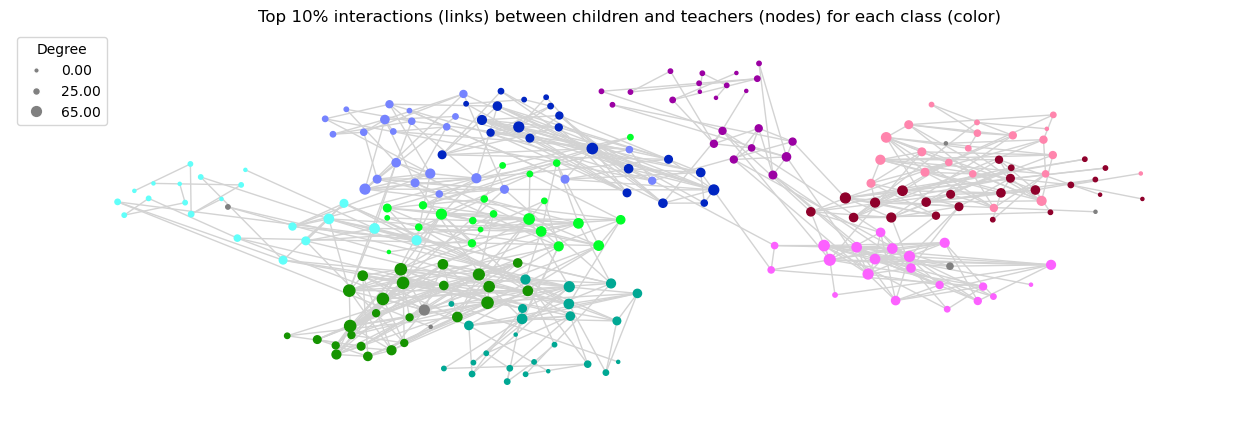

In [79]:
plot_network(G_plot, size_scale=5, size_metric="degree", title='Top 10% interactions (links) between children and teachers (nodes) for each class (color)')

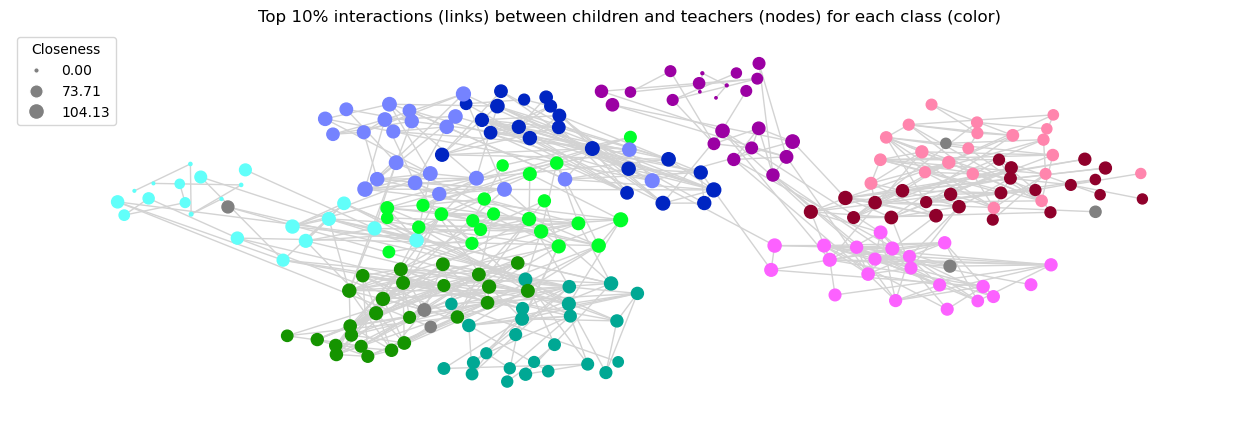

In [80]:
plot_network(G_plot, size_scale=450, size_metric="closeness", title='Top 10% interactions (links) between children and teachers (nodes) for each class (color)')

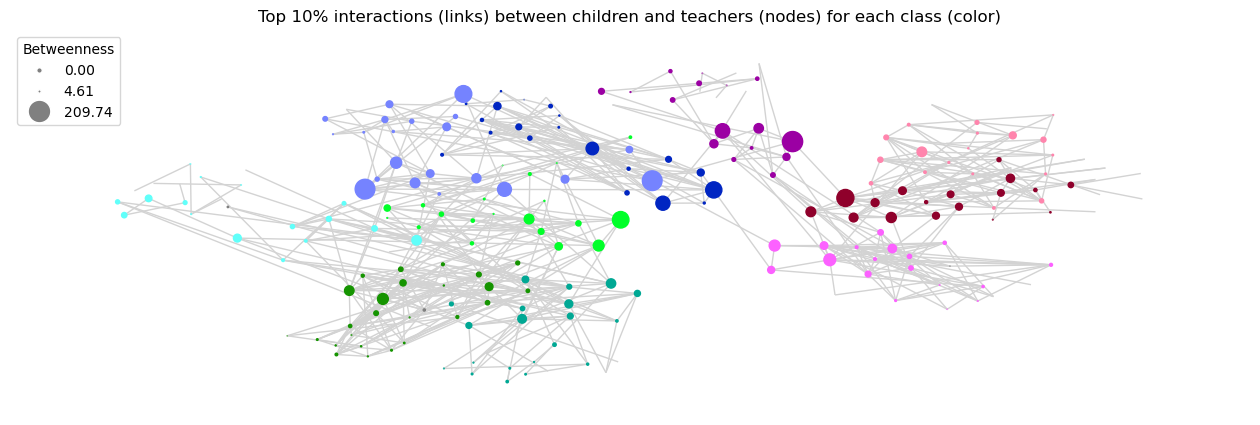

In [81]:
plot_network(G_plot, size_scale=950, size_metric="betweenness", title='Top 10% interactions (links) between children and teachers (nodes) for each class (color)')

Most interactions seem to happen within a class, which is to be expected.

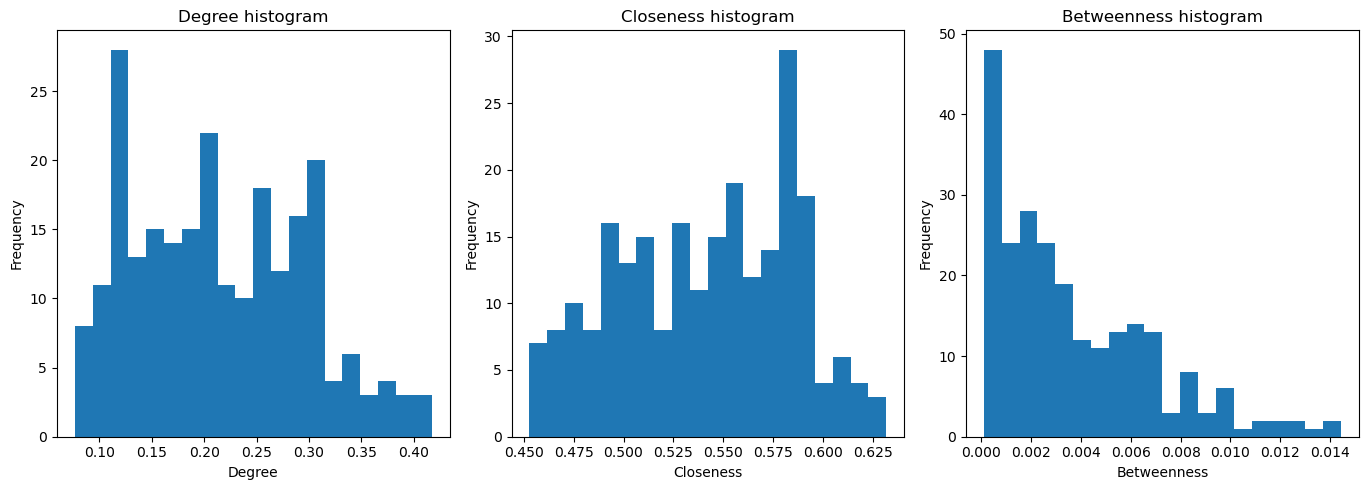

In [49]:
# centrality measures
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# dataframe with centralities and gender
metadata_df = pd.DataFrame({
    'node': list(G.nodes()),
    'degree': [degree_centrality[n] for n in G.nodes()],
    'closeness': [closeness_centrality[n] for n in G.nodes()],
    'betweenness': [betweenness_centrality[n] for n in G.nodes()]
})

metadata_df = metadata_df.merge(metadata, left_on='node', right_on='id', how='left')

# histograms by gender
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.flatten()

for idx, measure in enumerate(['degree', 'closeness', 'betweenness']):
    axes[idx].hist(metadata_df[measure], bins=20)
    axes[idx].set_xlabel(measure.capitalize())
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{measure.capitalize()} histogram')

plt.tight_layout()
plt.show()

All centrality measures seem to be right-tailed, meaning that there a few particularly central nodes for the respective measure. Betweenness is the most extreme case, where very few individuals seem to serve as a "bridge". 

## 3. Simulation

### 3.1 Infection model

Based on this [simulation study](https://www.nature.com/articles/s41598-022-14862-y) we assume infection to be a poisson process, where transmitting the critical viral load (to trigger infection) between two individuals happen randomly at a constant rate. PDF from the lecture:

$$
f_{PO}(k;\lambda)=\frac{\lambda^k}{k!}\exp(-\lambda)
$$

where $k$ is the number of critical viral loads transmitted, and $\lambda$ is the expected number of such events after certain time.

The probability to become infected is thus:

$$
P(\text{infected} \mid t) = P(k \ge 1)
= 1 - P(k=0)
= 1 - \exp(-\lambda ).
$$

If we want to express infection probability over time:

$$
P(t)=1-\exp(-\lambda t).
$$

The study simulated $P(t)$ in an indoor setting of continously speaking at 0.5, 1 and 2m distances. Since our data measures face-to-face interactions of at most 1.5m distance, indoor and outdoor, involving all kinds of activities, we conservatively estimate $\lambda$ from three points of their 2m face-to-face setting (see figure below from their paper):

$$P(infected \mid t=10) \approx 0.1$$

$$P(infected \mid t=50) \approx 0.4$$

$$P(infected \mid t=60) \approx 0.45$$

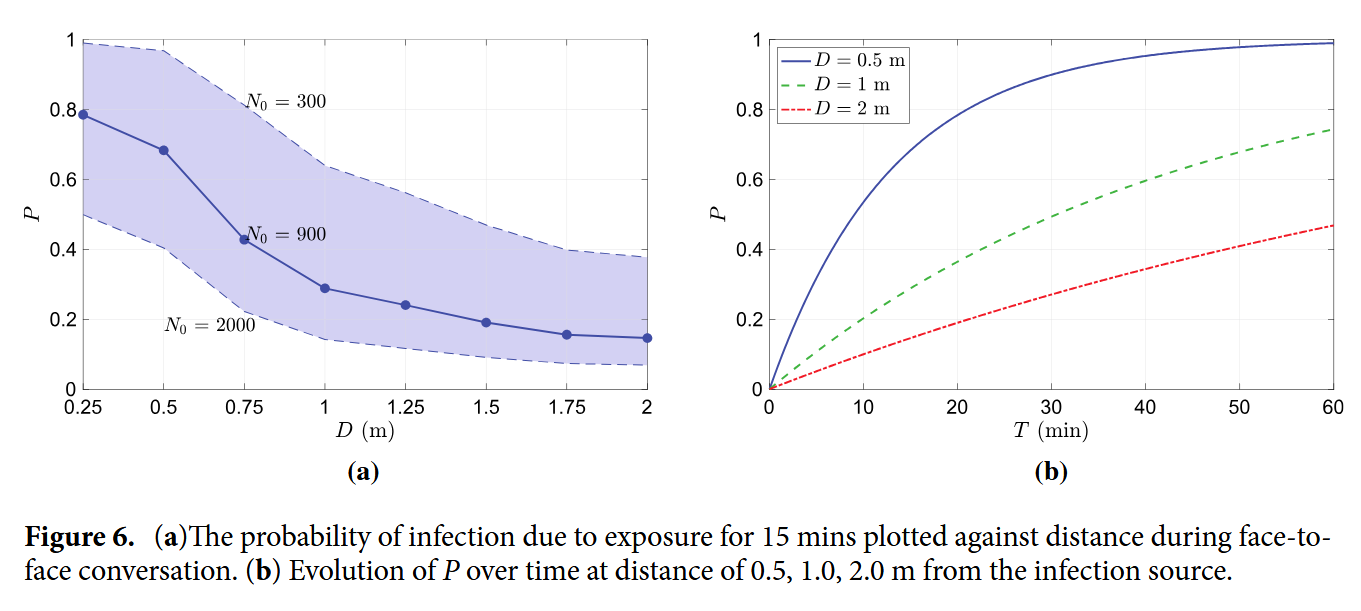

Using least squares we can estimate $\lambda$.

In [50]:
points = np.array([
    [10, 0.10],
    [50, 0.40],
    [60, 0.45],
], dtype=float)

t = points[:, 0]
p_obs = points[:, 1]

def infection_prob(lam, t):
    return 1 - np.exp(-lam * t)

def loss(lam):
    p_pred = infection_prob(lam, t)
    return np.sum((p_obs - p_pred) ** 2)

# simple grid search
grid = np.linspace(0, 1.0, 10000)
losses = np.array([loss(lam) for lam in grid])
lambda_hat = grid[np.argmin(losses)]

print("Best-fit lambda_hat:", lambda_hat)
print(p_obs, infection_prob(lambda_hat, t))

Best-fit lambda_hat: 0.010101010101010102
[0.1  0.4  0.45] [0.0960761  0.3965249  0.45450444]


Text(0, 0.5, '$P(infected \\mid t)$')

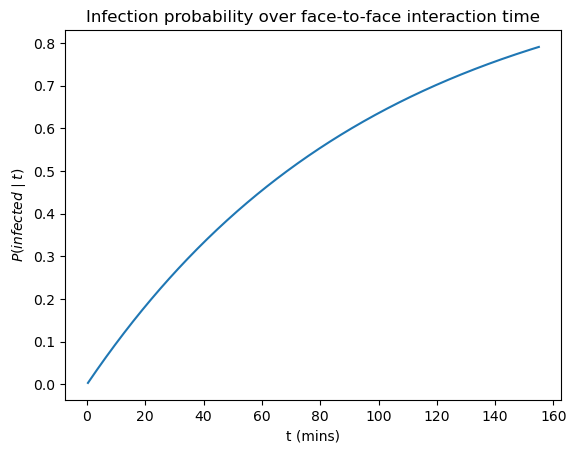

In [51]:
x = np.linspace(durations.min(), durations.max(), num=500)
plt.plot(x, infection_prob(lambda_hat, x))
plt.title('Infection probability over face-to-face interaction time')
plt.xlabel('t (mins)')
plt.ylabel('$P(infected \\mid t)$')

### 3.2 Epidemic model

The network starts with ``infected`` number of nodes. Each day the infection advances (``advance_infection``) and spreads (``infect``) based on the interaction patterns of the network using ``infection_prob``. 
During infection, nodes will go through three stages:
1) **Infected**: node is infected, but not yet infectious
2) **Infectious**: after ``t_infectious_range`` days (chosen randomly) node develops symptoms and becomes infectious
3) **Sick**: after ``t_sick_offset`` days infectious nodes becomes sick (go home) and can no longer infect other nodes (this is the same as returning immune eventually)

In [ ]:
# infect all neighbors according infection_prob
def infect(G, day, lam, t_infectious_range = (1, 3)):
    infectious_nodes = [n for n, v in nx.get_node_attributes(G, "infected").items() if v]    
    
    newly_infected = []
    for u in infectious_nodes:
        for v in G.neighbors(u):
            if not (G.nodes[v]["infected"] or G.nodes[v]["infectious"] or G.nodes[v]["sick"] or G.nodes[v]["immune"]):
                duration = G.edges[u, v]["duration"]
                if np.random.rand() < infection_prob(duration, lam):
                    newly_infected.append(v)

    for v in newly_infected:
        G.nodes[v]["infected"] = True
        G.nodes[v]["t_infected"] = day
        
        l, h = t_infectious_range
        t_infectious = np.random.randint(l, h + 1)
        G.nodes[v]["infectious"] = False
        G.nodes[v]["t_infectious"] = day + t_infectious
        
        G.nodes[v]['sick'] = False
        G.nodes[v]['t_sick'] = day + t_infectious + 1
        
    return G

# node infection status changes at the end of the day
def advance_infection(G, day):
    for n in G.nodes():
        ti = G.nodes[n].get("t_infectious")
        ts = G.nodes[n].get("t_sick")

        if ti is not None and day == ti:
            G.nodes[n]["infected"] = False
            G.nodes[n]["infectious"] = True

        if ts is not None and day == ts:
            G.nodes[n]["infected"] = False
            G.nodes[n]["infectious"] = False
            G.nodes[n]["sick"] = True

    return G
    
# simulate epidemic over a couple of days
def simulate_epidemic(G, 
                      days,
                      infected,
                      lam,
                      t_infectious_range,
                      t_sick_offset, 
                      immunized, 
                      immunized_p):
    G_current = G.copy()
    nx.set_node_attributes(G_current, False, "infected")
    nx.set_node_attributes(G_current, None, "t_infected")
    
    nx.set_node_attributes(G_current, False, "infectious")
    nx.set_node_attributes(G_current, None, "t_infectious")

    nx.set_node_attributes(G_current, False, "sick")
    nx.set_node_attributes(G_current, None, "t_sick")
        
    nx.set_node_attributes(G_current, False, "immune")

    # immunized
    immune_node_idx = np.random.choice(list(G_current.nodes), replace=False, size=immunized, p=immunized_p)
    for n in immune_node_idx:
        G_current.nodes[n]["immune"] = True
        
    # initial infected
    non_immune_nodes = [n for n, d in G_current.nodes(data=True) if not d.get("immune")]
    node_idx = random.sample(list(non_immune_nodes), infected)
    
    for n in node_idx:               
        G_current.nodes[n]["infected"] = True
        G_current.nodes[n]["t_infected"] = 0
        
        l, h = t_infectious_range
        t_infectious = np.random.randint(l, h + 1)
        G_current.nodes[n]["t_infectious"] = 0 + t_infectious
        
        G_current.nodes[n]['t_sick'] = 0 + t_infectious + t_sick_offset
    
    # infection day
    for day in range(days):        
        G_current = infect(G_current, day, lam, t_infectious_range)
        G_current = advance_infection(G_current, day)

    return G_current

### 3.3 Data generation

We start with one infected person and let each simulation run for 20 days, giving the epidemic enough time to reach a peak. Infected become infectious after 3-4 days and one day after they become sick/immune ([WHO](https://www.who.int/news-room/fact-sheets/detail/coronavirus-disease-(covid-19))).

For each run (same seed) we test following immunization strategies:

1. random uniform immunization 
2. degree centrality-biased immunization
3. closeness centrality-biased immunization
4. betweenness centrality-biased immunization

at immune ratios 5%, 10% and 15%. 

We define centrality-biased immunization, e.g. degree centrality-biased immunization (analogous for other centralites):

$$P(\text{node v immunized}) = \frac{\text{degree}(v)}{\sum_{u} degree(u)}$$

We do 300 repetitions per run to account for stochastic differences.

In [ ]:
# simulation parameters
n_repetitions = 300
infected = 1
days = 20
t_infectious_range = (3, 4)
t_sick_offset = 1
immune_ratios = [0.05, 0.10, 0.15]

# immunization probability for different interventions
n = len(G.nodes)
nodes = list(G.nodes)

immune_p_base = np.ones(n)/n

degrees = np.array([degree_centrality[v] for v in nodes])
immune_p_degree = degrees/np.sum(degrees)

closeness = np.array([closeness_centrality[v] for v in nodes])
immune_p_closeness = closeness/np.sum(closeness)

betweenness = np.array([betweenness_centrality[v] for v in nodes])
immune_p_betweenness = betweenness/np.sum(betweenness)

immune_ps = {
    'uniform': immune_p_base,
    'degree': immune_p_degree,
    'closeness': immune_p_closeness,
    'betweenness': immune_p_betweenness
}
 
# simulation already ran
if False:
    # immunization probability for different interventions
    n = len(G.nodes)
    nodes = list(G.nodes)

    immune_p_base = np.ones(n)/n

    degrees = np.array([degree_centrality[v] for v in nodes])
    immune_p_degree = degrees/np.sum(degrees)

    closeness = np.array([closeness_centrality[v] for v in nodes])
    immune_p_closeness = closeness/np.sum(closeness)

    betweenness = np.array([betweenness_centrality[v] for v in nodes])
    immune_p_betweenness = betweenness/np.sum(betweenness)

    res_i = []
    for immune_ratio in immune_ratios:
        immunized = int(n*immune_ratio)
        for group, immune_p in immune_ps.items():
            for i in range(n_repetitions):
                    # set same seed
                    random.seed(i)
                    np.random.seed(i)
                    
                    # run simulation
                    G_current = simulate_epidemic(G, infected=infected, days=days, lam=lambda_hat, t_infectious_range=t_infectious_range, t_sick_offset=t_sick_offset, immunized=immunized, immunized_p=immune_p)  
                    
                    # add data
                    t_infectious = nx.get_node_attributes(G_current, "t_infectious").values()
                    t_infectious_values = [t for t in t_infectious if t is not None]
                    counts = Counter(t_infectious_values)
                    for day, c in sorted(counts.items()):
                        res_i.append({
                            "run": i,
                            "day": day,
                            "group": group,
                            "n_infectious": c,
                            "immune_ratio": immune_ratio
                        })
                
        
    df = pd.DataFrame(res_i)
    df.to_csv('data/simulation_results_i.csv', index=False)

## 4. Inference statistics

### 4.1 Does centrality-biased immunization lead to a smaller peak outbreak vs random uniform immunization?

For each simulation run we compute the paired difference in peak infectious ratio (PIR) between uniform immunization and a given centrality-based strategy:

$$
\Delta PIR = PIR_{\text{uniform}} - PIR_{\text{centrality}}
$$

For each immune\_ratio and immunization strategy we perform a two-sided one-sample t-test (conceptually like paired t-test) on the differences. 

$$
H_0: \mu_{\Delta PIR} = 0
\quad \text{vs.} \quad
H_1: \mu_{\Delta PIR} \neq 0.
$$

This results in $3 \times 3 = 9$ separate tests. Let $\bar{X}$ be the sample mean of the $\Delta PIR$ values and $S$ their sample standard deviation. Our test statistic is the following (from the lecture):

$$
T = \frac{\bar{X}-0}{S/\sqrt{n}}
  = \frac{\bar{X}}{SE}.
$$

Under $H_0$: $T \sim t(n-1)$.

Each simulation run is treated as an independent draw and we assume that $T$ is approximately normally distributed. Sample size $n = 300$ per t-test.


In [ ]:
# data manipulations
nodes = list(G.nodes)

df = pd.read_csv('data/simulation_results_i.csv')
peak_df = (
    df.groupby(["run", "group", "immune_ratio"], as_index=False)
      .agg(peak_infectious=("n_infectious", "max"))
)

peak_df['peak_infectious'] /= len(nodes) # normalize from number of infectious -> ratio of infectious

wide = peak_df.pivot_table(
    index=["run", "immune_ratio"],
    columns="group",
    values="peak_infectious"
)

baseline = "uniform"
groups = ["betweenness", "closeness", "degree"]

rows = []
immune_levels = sorted(wide.index.get_level_values("immune_ratio").unique())

# tests
alpha = 0.05
for p in immune_levels:
    sub = wide.xs(p, level="immune_ratio")

    for g in groups:
        delta = (sub[g] - sub[baseline]).dropna()

        n = len(delta)
        mean_delta = delta.mean()
        sd = delta.std(ddof=1)
        se = sd / np.sqrt(n)

        t_stat = mean_delta / se
        dof = n - 1
        pval = 2*(1 - sp.stats.t.cdf(abs(t_stat), df=dof))
        
        # 95% CI
        tcrit = sp.stats.t.ppf(1-alpha/2, df=n-1)
        ci_half = tcrit * se
        
        rows.append({
            "immune_ratio": p,
            "group": g,
            "delta_pir": mean_delta,
            "ci_low": mean_delta - ci_half,
            "ci_high": mean_delta + ci_half,
            "t_stat": t_stat,
            "p_value": np.round(pval, 6),
            "n": n
        })

summary = pd.DataFrame(rows)

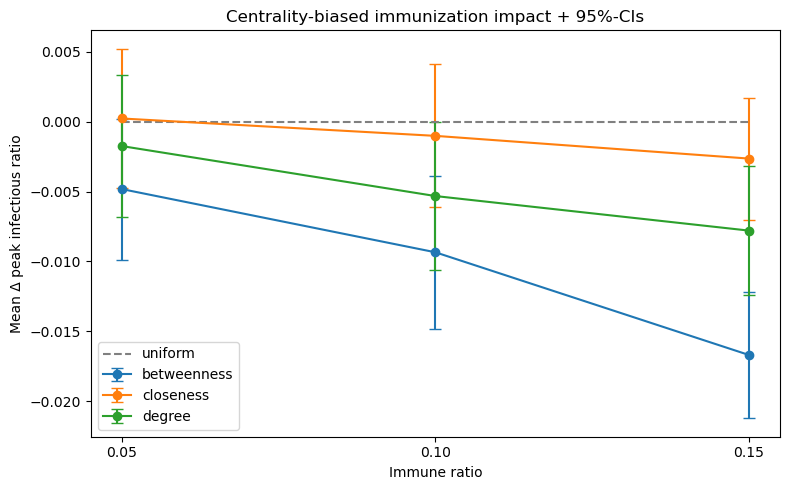

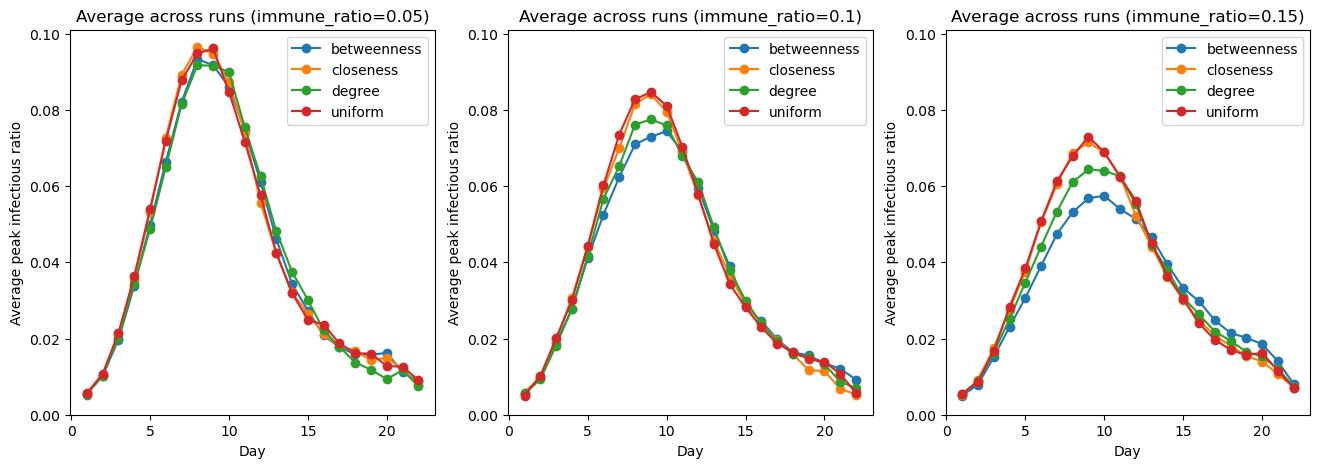

In [91]:
# data preparation
daily_counts = (
    df.groupby(["day", "group", "immune_ratio"], as_index=False)
      .agg(r_infectious=("n_infectious", "mean"))
)

daily_counts['r_infectious'] /= len(nodes)

# plot 1 
plt.figure(figsize=(8, 5))

for g in groups:
    s = summary[summary["group"] == g].sort_values("immune_ratio")

    x = s["immune_ratio"].to_numpy()
    y = s["delta_pir"].to_numpy()
    yerr = (s["ci_high"] - s["delta_pir"]).to_numpy()

    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4, label=g)

plt.xlabel("Immune ratio")
plt.ylabel("Mean Δ peak infectious ratio")
plt.title("Centrality-biased immunization impact + 95%-CIs")
plt.xticks(immune_ratios)
plt.hlines(0.0, immune_ratios[0], immune_ratios[-1], linestyles='dashed', colors='gray', label='uniform')
plt.legend()
plt.tight_layout()
plt.show()

# plot 2
fig, ax = plt.subplots(ncols = 3, figsize=(16, 5))

for i, immune_ratio in enumerate(daily_counts['immune_ratio'].unique()):
    for group in daily_counts['group'].unique():
        group_data = daily_counts[(daily_counts['group'] == group) & (daily_counts['immune_ratio'] == immune_ratio)]
        ax[i].plot(group_data['day'], group_data['r_infectious'], marker='o', label=group)
        ax[i].set_title(f'Average across runs (immune_ratio={immune_ratio})')
        ax[i].set_xlabel('Day')
        ax[i].set_ylabel('Average peak infectious ratio')
        ax[i].legend()
        
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1], ax[2].get_ylim()[1])
ax[0].set_ylim(0, y_max)
ax[1].set_ylim(0, y_max)
ax[2].set_ylim(0, y_max)
plt.show()

In [92]:
i = (summary['p_value'] < alpha) & (summary['delta_pir'] < 0)
res_sig = summary[i]
res_sig

,immune_ratio,group,delta_pir,ci_low,ci_high,t_stat,p_value,n
3,0.10,betweenness,-0.009350,-0.014826,-0.003874,-3.360339,0.000880,300
5,0.10,degree,-0.005325,-0.010645,-0.000005,-1.969713,0.049794,300
6,0.15,betweenness,-0.016695,-0.021230,-0.012160,-7.244631,0.000000,300
8,0.15,degree,-0.007797,-0.012421,-0.003172,-3.318050,0.001019,300


Our simulation shows that after ~9 days we reach the peak fraction of infectious. Unsurprisingly, this number is affected by the immune_ratio and ranges between ~10% to ~8% of the population (n=236).

Betweenness-biased immunization significantly reduces the peak infectious ratio vs uniform ($\Delta PIR$) across all immunization levels compared to uniform immunization ($\alpha=0.05$). This effect is most pronounced at 15% immunization, where the peak fraction infected is reduced by about 1.7% (ΔPIR = −0.017, 95% CI [-0.021, -0.012], t = -7.24, p << 0.05).

Degree-biased immunization also significantly reduces the peak infectious ratio at 10% and 15% immunization, with largest effect about 0.8% (ΔPIR = −0.008, 95% CI [-0.012, -0.003], t = -3.31, p = 0.0001). In contrast, closeness-biased immunization shows no statistically significant reduction in PIR across any of the immunization levels.

Overall, the estimated effects are relatively small, e.g. for this social network a reduction of 1.7% corresponds to 4 fewer infectious individuals at the peak infectious day. One reason may be that we apply biased-centrality immunization rather than deterministically immunizing the highest-centrality nodes. Selecting the top-ranked centrality nodes would likely lead to a larger effect. However, I intentionally chose the biased approach because firstly in reality, it is typically not possible to know the true global centrality measures in advance and secondly I know about a degree-biased sampling approach using the [friendship paradox](https://en.wikipedia.org/wiki/Friendship_paradox), which is much more feasible in a real world setting.

### 4.2 Is friendship sampling the same as degree-biased sampling? 

The friendship paradox states that on average, your friends have more friends than you do. This is a form of sampling bias, where selecting a random neighbor from a node is more likely to have high degree. Turning to immunization strategies the approach would be to pick a fraction of the population (``immune_ratio``) at uniform random and instead of immunizing them, immunize a random neighbor, i.e. someone they have interacted with at that day. I would suspect that this form of immunization should reproduce something close to our degree-biased immunization. In the real world this would be easier to achieve, because instead of tracking the whole school we just have to ask a fraction about whom they spent time with.

To test this hypothesis we will perform a chi-square goodness-of-fit test comparing observed degree distributions of friendship sampling vs degree-biased sampling (from lecture):

$$
H_0 : P(X_i = j) = p_j, \quad j = 1, \dots, k \quad \text{vs.} \quad
H_1 : P(X_i = j) \ne p_j \quad \text{for at least one } j
$$

where $X_i$ is the degree bin of immunized individual $i$, $k$ is the number of degree bins and $p_j$ is the expected probability of degree bin $j$ under the degree-biased immunization strategy.

With test statistic T (from lecture):

$$T = \sum_{j=1}^{k} \frac{(Y_j - n p_j)^2}{n p_j}
$$

where $Y_j$ is the observed number of counts in bin $j$, $p_j$ is the expected probability of bin $j$. 

Under $H0$: $T \sim \chi^2_{k-1}$

Result of simulation with n = 10000


(-1120.875, 1120.875)

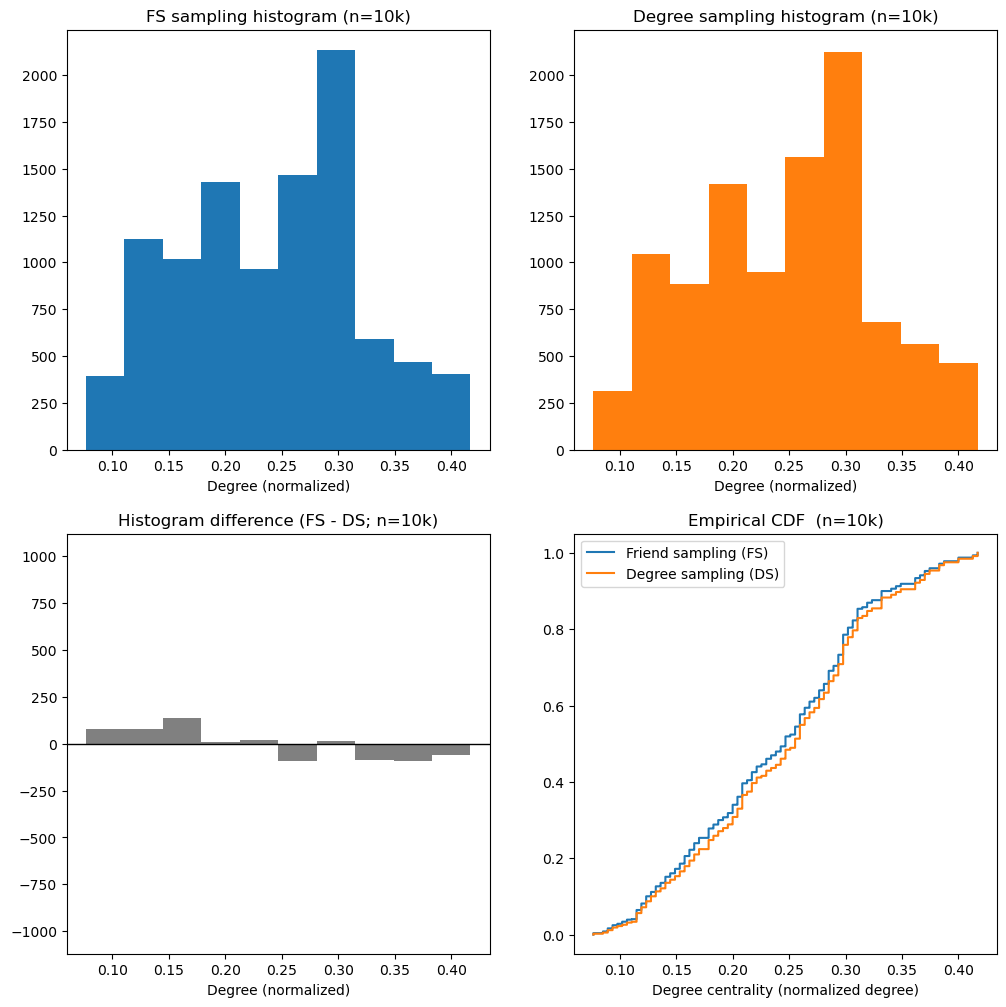

In [89]:
def simulate_friend_sampling(G, n):
    nodes = list(G.nodes())
    degree_centrality = nx.degree_centrality(G)
    degree_sample = []
    node_sample = []

    sampled_nodes = random.choices(nodes, k=n)
    for u in sampled_nodes:
        neighbors = list(G.neighbors(u))
        if neighbors:
            friend = random.choice(neighbors)
            
            degree = degree_centrality[friend]
            degree_sample.append(degree)
            node_sample.append(friend)
    return degree_sample, node_sample
    
def simulate_degree_sampling(G, n):
    nodes = list(G.nodes())
    degree_centrality = nx.degree_centrality(G)
    degrees = np.array([degree_centrality[v] for v in nodes])
    sampling_p = degrees/np.sum(degrees)
    degree_sample = []
    
    sampled_nodes = np.random.choice(nodes, size=n, p=sampling_p)
    for u in sampled_nodes:
        degree = degree_centrality[u]
        degree_sample.append(degree)

    return degree_sample

# plot differences
n = 10000
bins = 10

print(f'Result of simulation with n = {n}')

def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs = axs.flatten()

# hist 1 
degrees_fs, nodes_fs = simulate_friend_sampling(G, n)
axs[0].hist(degrees_fs, bins=bins)
axs[0].set_title(f'FS sampling histogram (n={n//1000}k)')
axs[0].set_xlabel('Degree (normalized)')

# hist 2
degrees_ds = simulate_degree_sampling(G, n)
axs[1].hist(degrees_ds, bins=bins, color='tab:orange')
axs[1].set_title(f'Degree sampling histogram (n={n//1000}k)')
axs[1].set_xlabel('Degree (normalized)')

# hist diff
all_degrees = np.concatenate([degrees_fs, degrees_ds])
bins = np.histogram_bin_edges(all_degrees, bins=bins)

hist_fs, _ = np.histogram(degrees_fs, bins=bins)
hist_ds, _ = np.histogram(degrees_ds, bins=bins)

hist_diff = hist_fs - hist_ds
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = np.diff(bins)

# Hist diff (FS - DS)
axs[2].bar(bin_centers, hist_diff, width=bin_widths, align="center", color='grey')
axs[2].axhline(0, color="black", linewidth=1)
axs[2].set_title(f'Histogram difference (FS - DS; n={n//1000}k)')
axs[2].set_xlabel('Degree (normalized)')

# ECDF
x1, y1 = ecdf(degrees_fs)
x2, y2 = ecdf(degrees_ds)
axs[3].step(x1, y1, where="post", label="Friend sampling (FS)")
axs[3].step(x2, y2, where="post", label="Degree sampling (DS)")
axs[3].set_title(f'Empirical CDF  (n={n//1000}k)')
axs[3].set_xlabel('Degree centrality (normalized degree)')
axs[3].legend()

# same y-axis limits
y_max = max(axs[0].get_ylim()[1], axs[1].get_ylim()[1])
axs[0].set_ylim(0, y_max)
axs[1].set_ylim(0, y_max)
axs[2].set_ylim(-y_max/2, y_max/2)

In [87]:
expected_counts > 5

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [58]:
observed_counts = hist_fs
expected_counts = hist_ds

chi2_stat, p_value = sp.stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 102.40570855514791
p-value: 5.127181529282504e-18


Chi-square goodness-of-fit test shows that the degree distributions are not the same. FS seems to be marginally favoring smaller degrees. Although this effect is relatively small the result is highly significant. This is to be expected for large n (10k) and $H1$ being true leading to high power.

### 4.3 Impact of friendship sampling

Even though the distributions are not the same, their impact on peak infectious ratio might be. Again we use the same one sample t-test on paired differences from previous section:

$$
\Delta PIR = PIR_{\text{uniform}} - PIR_{\text{friendship/degree-biased}}
$$

For each immune\_ratio and immunization strategy we perform a two-sided one-sample t-test on the differences:

$$
H_0: \mu_{\Delta PIR} = 0
\quad \text{vs.} \quad
H_1: \mu_{\Delta PIR} \neq 0.
$$

In [ ]:
# get immunization probability
node_counts = Counter(nodes_fs) # how often each node was drawn in fs sampling
node_counts = np.array([node_counts.get(v, 0) for v in nodes]) # reorder them according to nodes in G
immune_p_fs = node_counts / np.sum(node_counts)

# simulation already ran
if False:
    # immunization probability for different interventions
    n = len(G.nodes)
    nodes = list(G.nodes)
        
    res_fs = []
    for immune_ratio in immune_ratios:
        immune = int(n*immune_ratio)
        for i in range(n_repetitions):
            # set same seed
            random.seed(i)
            np.random.seed(i)
                
            # friendship immunization
            G_current = simulate_epidemic(G, infected=infected, days=days, lam=lambda_hat, t_infectious_range=t_infectious_range, t_sick_offset=t_sick_offset, immunized=immune, immunized_p=immune_p_fs)  
            
            # add data
            t_infectious = nx.get_node_attributes(G_current, "t_infectious").values()
            t_infectious_values = [t for t in t_infectious if t is not None]
            counts = Counter(t_infectious_values)
            for day, c in sorted(counts.items()):
                res_fs.append({
                    "run": i,
                    "day": day,
                    "group": "friendship",
                    "n_infectious": c,
                    "immune_ratio": immune_ratio
                })
    
    df = pd.DataFrame(res_fs)
    df.to_csv('data/simulation_results_fs.csv', index=False)

In [ ]:
# data manipulations
nodes = list(G.nodes)

df1 = pd.read_csv('data/simulation_results_fs.csv')
df2 = pd.read_csv('data/simulation_results_i.csv')
df = pd.concat([df1, df2], ignore_index=True)

peak_df = (
    df.groupby(["run", "group", "immune_ratio"], as_index=False)
      .agg(peak_infectious=("n_infectious", "max"))
)

peak_df['peak_infectious'] /= len(nodes) # normalize from number of infectious -> ratio of infectious

wide = peak_df.pivot_table(
    index=["run", "immune_ratio"],
    columns="group",
    values="peak_infectious"
)

baseline = "uniform"
groups = ["friendship", "degree"]

rows = []
immune_levels = sorted(wide.index.get_level_values("immune_ratio").unique())

# tests
alpha = 0.05
for p in immune_levels:
    sub = wide.xs(p, level="immune_ratio")

    for g in groups:
        delta = (sub[g] - sub[baseline]).dropna()

        n = len(delta)
        mean_delta = delta.mean()
        sd = delta.std(ddof=1)
        se = sd / np.sqrt(n)

        t_stat = mean_delta / se
        dof = n - 1
        pval = 1 - sp.stats.t.cdf(abs(t_stat), df=dof)
        
        # 95% CI
        tcrit = sp.stats.t.ppf(1-alpha/2, df=n-1)
        ci_half = tcrit * se
        
        rows.append({
            "immune_ratio": p,
            "group": g,
            "mean_delta": mean_delta,
            "ci_low": mean_delta - ci_half,
            "ci_high": mean_delta + ci_half,
            "t_stat": t_stat,
            "p_value": np.round(pval, 6),
            "n": n
        })

summary = pd.DataFrame(rows)

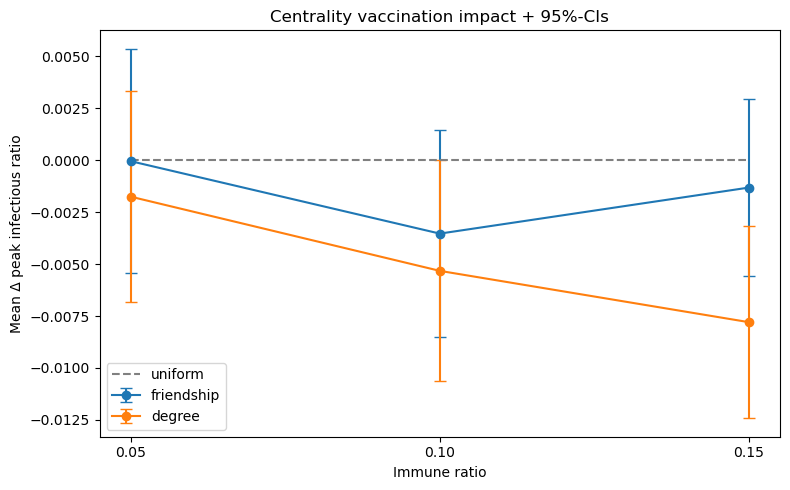

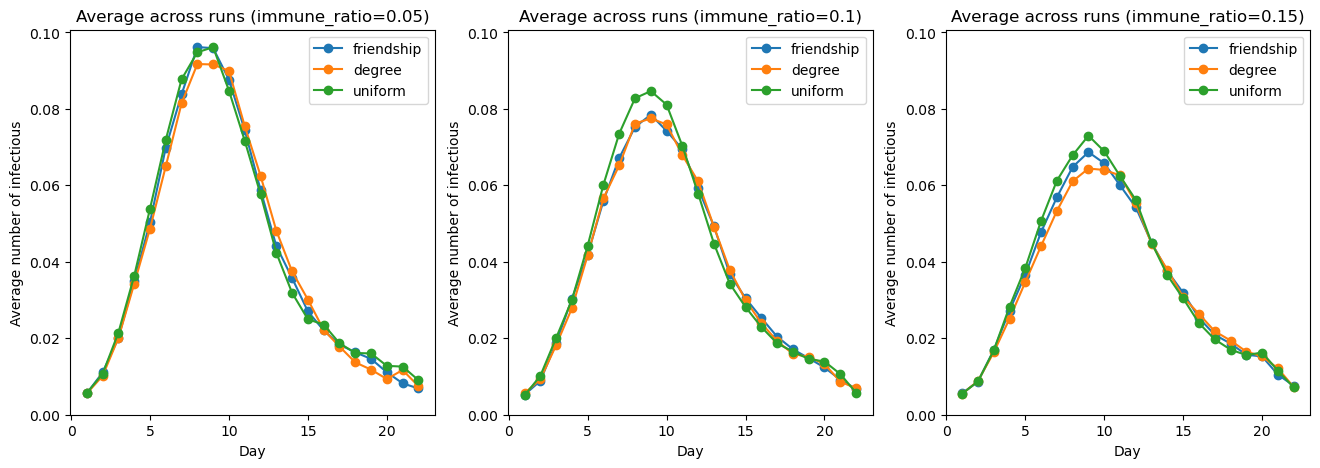

In [66]:
# data preparation
daily_counts = (
    df.groupby(["day", "group", "immune_ratio"], as_index=False)
      .agg(r_infectious=("n_infectious", "mean"))
)

daily_counts['r_infectious'] /= len(nodes)

# plot 1 
plt.figure(figsize=(8, 5))

for g in groups:
    s = summary[summary["group"] == g].sort_values("immune_ratio")

    x = s["immune_ratio"].to_numpy()
    y = s["mean_delta"].to_numpy()
    yerr = (s["ci_high"] - s["mean_delta"]).to_numpy()

    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4, label=g)

plt.xlabel("Immune ratio")
plt.ylabel("Mean Δ peak infectious ratio")
plt.title("Centrality vaccination impact + 95%-CIs")
plt.xticks(immune_ratios)
plt.hlines(0.0, immune_ratios[0], immune_ratios[-1], linestyles='dashed', colors='gray', label='uniform')
plt.legend()
plt.tight_layout()
plt.show()

# plot 2
fig, ax = plt.subplots(ncols = 3, figsize=(16, 5))

for i, immune_ratio in enumerate(daily_counts['immune_ratio'].unique()):
    filtered_groups = [g for g in groups] + [baseline]
    for group in filtered_groups:
        group_data = daily_counts[(daily_counts['group'] == group) & (daily_counts['immune_ratio'] == immune_ratio)]
        ax[i].plot(group_data['day'], group_data['r_infectious'], marker='o', label=group)
        ax[i].set_title(f'Average across runs (immune_ratio={immune_ratio})')
        ax[i].set_xlabel('Day')
        ax[i].set_ylabel('Average number of infectious')
        ax[i].legend()
        
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1], ax[2].get_ylim()[1])
ax[0].set_ylim(0, y_max)
ax[1].set_ylim(0, y_max)
ax[2].set_ylim(0, y_max)
plt.show()

In [67]:
i = (summary['p_value'] < alpha) & (summary['mean_delta'] < 0)
res_sig = summary[i]
res_sig

,immune_ratio,group,mean_delta,ci_low,ci_high,t_stat,p_value,n
3,0.10,degree,-0.005325,-0.010645,-0.000005,-1.969713,0.024897,300
5,0.15,degree,-0.007797,-0.012421,-0.003172,-3.318050,0.000509,300


Friendship immunization does not perform significantly better than uniform at any immunization ratios. It seems to be slightly worse than degree-biased sampling, undersampling larger degrees to a small degree. 

# 5. Conclusion and caveat

In this project, we found that both betweenness-biased and degree-biased immunization strategies reduced the peak infectious ratio (PIR) compared to uniform random immunization at low vaccination coverage. Among the strategies considered, betweenness-biased immunization was the most effective. This makes sense as betweenness serves as a bridge within the network and is thus important for information (in this case infection) flow. 

To explore a more practically implementable approach, we evaluated a friendship-paradox–based immunization strategy. Although this method is designed to preferentially reach higher-degree individuals, it did not perform significantly better than uniform sampling in terms of reducing PIR.

Overall, effect sizes were small. Even the strongest intervention (betweenness-biased immunization at 15% coverage) reduced the PIR by only about 1.7 percentage points. In this specific network and model setting, this suggests that uniform vaccination performs comparably well. Note that immunizing the top centrality nodes would be more effective, but we chose the biased approach with the friendship paradox in mind, since knowing the whole network structure is unfeasible in practice.

These findings are strongly model-dependent. While the network structure is defendable if we want to draw conclusions about epidemics in primary schools, the infection modelling was done a bit hand-wavy. Changing the infection probability, when people become infectious or sick and immunization ratio would probably drastically change the results. 